(certainty_equiv_robustness)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 确定性等价与模型不确定性

```{index} single: Certainty Equivalence; Robustness
```

```{index} single: LQ Control; Permanent Income
```

```{contents} Contents
:depth: 2
```



## 概述


本讲是 [关于确定性等价的这一讲](theil_1) 的续篇，该讲为线性二次型（LQ）动态规划问题建立了一个重要的*确定性等价*（CE）性质。

该性质证明了一个用于计算最优决策规则的两步算法是合理的：

1. 在完全预见下*优化*（将未来外生变量视为已知）。
2. *预测* —— 用最优预测替换未知的未来值。

本讲受 {cite}`hansen2004certainty` 的启发，从两个方向扩展了确定性等价性质：

- *模型不确定性与稳健性。* 当决策者不信任自己的模型时会发生什么？CE 的一个显著版本依然成立，但现在"预测"步骤使用一个*扭曲的*概率分布，决策者为了实现稳健性而故意将其向不利于自己的方向倾斜。

- *风险敏感偏好。* 一个数学上等价的重新表述通过递归风险敏感偏好来解释同样的决策规则。

  稳健性参数 $\theta$ 与风险敏感性参数 $\sigma$ 通过 $\theta = -\sigma^{-1}$ 相联系。

我们用 `quantecon` 的 Python 代码来说明所有这三种设定 —— 普通 CE、稳健 CE 以及永久收入应用。

### 模型特征

* 线性转移律与二次目标（LQ 框架）。
* 普通 CE：最优策略与噪声方差无关。
* 稳健 CE：扭曲的预测取代基准模型的预测；策略函数取决于 $\theta$。
* 永久收入应用：Hall 的鞅、稳健性下的预防性储蓄，以及稳健性与耐心之间的观测等价性。


本讲借鉴了 {cite}`hansen2004certainty` 和 {cite}`HansenSargent2008`。

除了 Anaconda 中已有的库之外，本讲还需要以下库：

In [1]:
!pip install quantecon

我们使用以下导入：

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from quantecon import LQ, RBLQ
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 回顾：普通确定性等价

{ref}`配套讲座 <certainty_equiv_theil1>` 详细地建立了 CE 性质。

这里我们只收集下面稳健性扩展所需的要素。

状态向量 $y_t = \begin{bmatrix} x_t \\ z_t \end{bmatrix}$ 有一个外生分量 $z_t$，其转移律为

```{math}
:label: eq:z_transition_o
z_{t+1} = f(z_t,\, \epsilon_{t+1})
```

和一个内生分量 $x_t$，服从

```{math}
:label: eq:x_transition_o
x_{t+1} = g(x_t,\, z_t,\, u_t).
```

在 LQ 假设下（二次收益 $r(y,u) = -y^\top Qy - u^\top Ru$，线性的 $f$ 和 $g$，高斯冲击），最优决策规则 $h$ 分解为 $u_t = h_1(x_t,\, h_2 \cdot z_t)$，其中 $h_1$ 求解一个非随机控制问题，$h_2$ 求解一个最优预测问题。

最优值函数为 $V(y_0) = -y_0^\top P\, y_0 - p$，其中，写 $z_{t+1} = f_1 z_t + f_2 \epsilon_{t+1}$：

- $P$ 是算子 $T(P; r, g, f_1)$ 的不动点，该算子*不*涉及波动率矩阵 $f_2$，因此 $P$ 和决策规则 $h$ 都不依赖于噪声载荷。

- 常数 $p = \beta/(1-\beta)\,\mathrm{tr}(f_2^\top P f_2)$ 随波动率增大。

不确定性降低了值（更大的 $p$），但不改变行为。

以下代码设置了一个标量 LQ 问题，并确认策略增益 $F$ 对噪声水平 $\sigma$ 不变，而 $d$ 随其增大。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


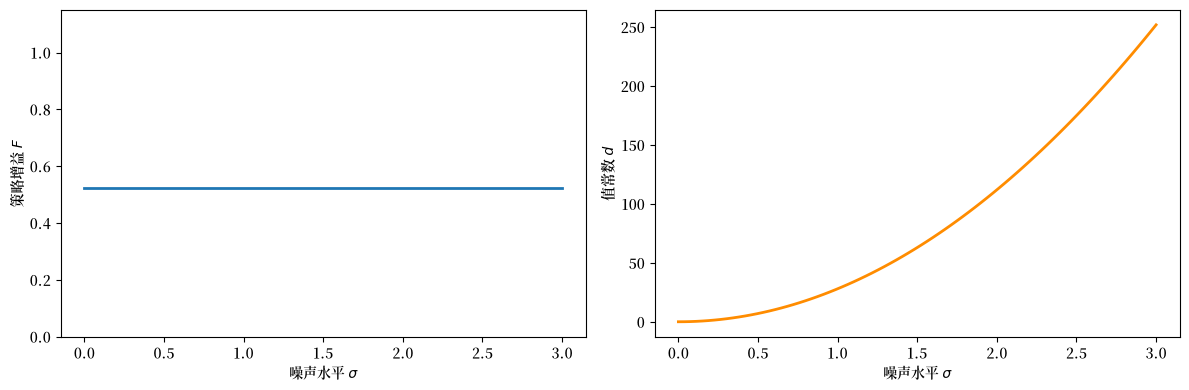

In [3]:
a, b_coeff = 0.9, 1.0
q, r = 1.0, 1.0
β = 0.95

A = np.array([[a]])
B = np.array([[b_coeff]])
Q_mat = np.array([[q]])          # 状态成本
R_mat = np.array([[r]])          # 控制成本

σ_vals = np.linspace(0.0, 3.0, 80)
F_vals, d_vals = [], []

for σ in σ_vals:
    C = np.array([[σ]])
    lq = LQ(R_mat, Q_mat, A, B, C=C, beta=β)
    P, F, d = lq.stationary_values()
    F_vals.append(float(F[0, 0]))
    d_vals.append(float(d))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(σ_vals, F_vals, lw=2)
axes[0].set_xlabel('噪声水平 $\\sigma$')
axes[0].set_ylabel('策略增益 $F$')
axes[0].set_ylim(0, 2 * max(F_vals) + 0.1)

axes[1].plot(σ_vals, d_vals, lw=2, color='darkorange')
axes[1].set_xlabel('噪声水平 $\\sigma$')
axes[1].set_ylabel('值常数 $d$')

plt.tight_layout()
plt.show()

## 模型不确定性与稳健性

### 设定与乘数问题

在 Simon 和 Theil 的设定中，决策者精确地知道自己的模型 —— 他对转移律 {eq}`eq:z_transition_o` 毫无疑问。

现在假设他怀疑真实的数据生成过程是

```{math}
:label: eq:distorted_law
z_{t+1} = f(z_t,\; \epsilon_{t+1} + w_{t+1})
```

其中 $w_{t+1} = \omega_t(x^t, z^t)$ 是由对抗性的"自然"所选择的误设项。

决策者相信他的近似模型是一个良好的近似，其含义是

```{math}
:label: eq:misspec_budget
\hat{\mathbb{E}}\!\left[\sum_{t=0}^{\infty} \beta^t\, w_{t+1}^\top w_{t+1}
      \,\Big|\, y_0\right] \leq \eta_0,
```

其中 $\eta_0$ 参数化了容许的误设预算，$\hat{\mathbb{E}}$ 是在扭曲律 {eq}`eq:distorted_law` 下的期望。

为了构造一个*稳健*的决策规则，决策者求解**乘数问题** —— 一个双人零和动态博弈：

```{math}
:label: eq:multiplier
\min_{\{w_{t+1}\}}\, \max_{\{u_t\}}\;
\hat{\mathbb{E}}\!\left[\sum_{t=0}^{\infty} \beta^t
    \Bigl\{r(y_t, u_t) + \theta\beta\, w_{t+1}^\top w_{t+1}\Bigr\}\,
    \Big|\, y_0\right]
```

其中 $\theta > 0$ 惩罚大的扭曲。

更大的 $\theta$ 会收缩可行的误设集合；当 $\theta \to \infty$ 时，问题退化为普通 LQ。

{eq}`eq:multiplier` 的马尔可夫完美均衡给出一个*稳健*规则 $u_t = h(x_t, z_t)$ 以及一个最坏情形扭曲过程 $w_{t+1} = W(x_t, z_t)$。

### Stackelberg 时序与修正后的 CE

马尔可夫完美均衡*隐藏*了一种形式的 CE。

为了揭示它，{cite:t}`HansenSargent2001` 施加了一个 **Stackelberg 时序协议**：在时刻 0，*最小化*方一劳永逸地承诺一个计划 $\{w_{t+1}\}$，之后*最大化*方顺序地选择 $u_t$。

这使得最小化方成为 Stackelberg 领导者。

为了描述领导者所承诺的计划，引入"大写字母"状态变量 $(X_t, Z_t)$（维数与 $(x_t, z_t)$ 相同），用于编码领导者预先承诺的策略：

```{math}
:label: eq:stackelberg_plan
\begin{aligned}
w_{t+1} &= W(X_t, Z_t), \\
X_{t+1} &= g(X_t, Z_t,\, h(X_t, Z_t)), \\
Z_{t+1} &= f(Z_t,\, W(X_t, Z_t) + \epsilon_{t+1}).
\end{aligned}
```

用 $Y_t = \begin{bmatrix} X_t \\ Z_t \end{bmatrix}$ 概括为：

```{math}
:label: eq:stackelberg_law
Y_{t+1} = M Y_t + N \epsilon_{t+1}, \qquad w_{t+1} = W(Y_t).
```

然后最大化方面对一个*普通*动态规划问题，服从他自身的动态 {eq}`eq:x_transition_o`、扭曲的 $z$ 律 {eq}`eq:distorted_law` 以及外生过程 {eq}`eq:stackelberg_law`。

他的最优规则取如下形式

```{math}
:label: eq:max_rule
u_t = \tilde{H}(x_t, z_t, Y_t).
```

{cite:t}`bacsar2008h` 和 {cite:t}`HansenSargent2008` 证明了，在均衡处（施加"大 $K$ = 小 $k$"），这退化为

```{math}
:label: eq:equilibrium_rule
\tilde{H}(X_t, Z_t, Y_t) = h(Y_t),
```

即与 {eq}`eq:multiplier` 的马尔可夫完美均衡*相同*的规则。

### 修正后的分离原理

Stackelberg 时序允许采用欧拉方程方法。

两步算法变为：

第一步不变：求解与之前相同的非随机控制问题，将 $\mathbf{z}_t = (z_t, z_{t+1}, \ldots)$ 视为已知，得到 $u_t = h_1(x_t, \mathbf{z}_t)$。

第二步被修改：使用*扭曲的*运动律 {eq}`eq:stackelberg_law` 来形成预测。由于系统的线性性和高斯性，

```{math}
:label: eq:distorted_forecast
\hat{\mathbb{E}}[\mathbf{z}_t \mid z^t, Y^t]
    = \hat{h}_2 \begin{bmatrix} z_t \\ Y_t \end{bmatrix}
```

其中 $\hat{\mathbb{E}}$ 使用扭曲的模型。

将 {eq}`eq:distorted_forecast` 代入 $h_1$ 并施加 $Y_t = y_t$，得到稳健规则

```{math}
:label: eq:robust_ce_rule
u_t = h_1\!\left(x_t,\; \hat{h}_2 \cdot y_t\right) = h(x_t, z_t).
```

这就是修正后的 CE：*第一步与非稳健情形完全相同*；只有第二步改变，使用扭曲的而非理性的预测。

与普通 CE 相反，稳健策略*确实*随 $\theta$ 变化而改变。

当 $\theta \to \infty$（无稳健性）时，稳健策略收敛到标准 LQ 策略。

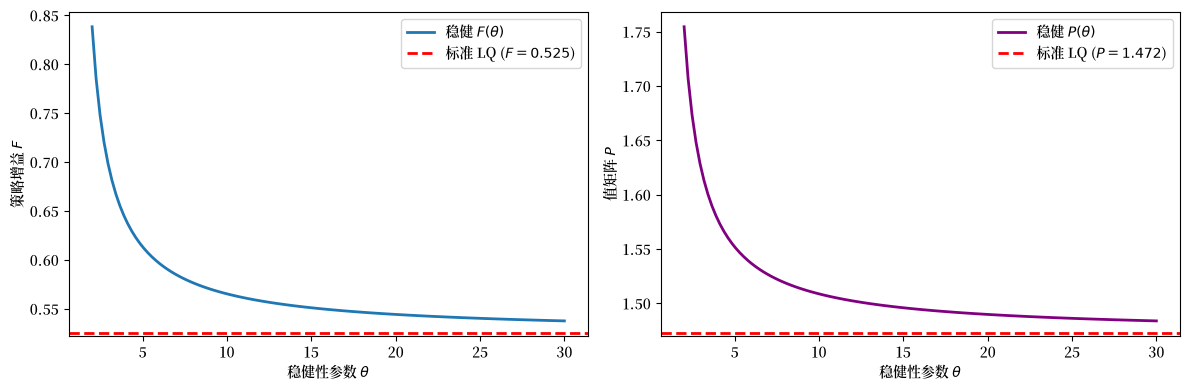

In [4]:
σ_fixed = 1.0
C_fixed = np.array([[σ_fixed]])

lq_std = LQ(R_mat, Q_mat, A, B, C=C_fixed, beta=β)
P_std, F_std_arr, d_std = lq_std.stationary_values()
F_standard = float(F_std_arr[0, 0])
P_standard = float(P_std[0, 0])

θ_vals = np.linspace(2.0, 30.0, 120)   # 将注意力限制在数值稳定的范围内
F_rob_vals, P_rob_vals = [], []

for θ in θ_vals:
    rblq = RBLQ(R_mat, Q_mat, A, B, C_fixed, β, θ)
    F_rob, K_rob, P_rob = rblq.robust_rule()
    F_rob_vals.append(float(F_rob[0, 0]))
    P_rob_vals.append(float(P_rob[0, 0]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(θ_vals, F_rob_vals, lw=2, label='稳健 $F(\\theta)$')
axes[0].axhline(F_standard, color='r', linestyle='--', lw=2,
                label=f'标准 LQ ($F = {F_standard:.3f}$)')
axes[0].set_xlabel('稳健性参数 $\\theta$')
axes[0].set_ylabel('策略增益 $F$')
axes[0].legend()

axes[1].plot(θ_vals, P_rob_vals, lw=2, color='purple',
             label='稳健 $P(\\theta)$')
axes[1].axhline(P_standard, color='r', linestyle='--', lw=2,
                label=f'标准 LQ ($P = {P_standard:.3f}$)')
axes[1].set_xlabel('稳健性参数 $\\theta$')
axes[1].set_ylabel('值矩阵 $P$')
axes[1].legend()

plt.tight_layout()
plt.show()

观察到，对于较小的 $\theta$（对稳健性有强烈偏好），$F$ 和 $P$ 都显著偏离它们的非稳健对应值，并随 $\theta \to \infty$ 收敛到标准值。

这与普通 CE 形成鲜明对比：在稳健性下，*策略增益和值矩阵都依赖于稳健性参数 $\theta$ 和噪声载荷矩阵 $C$*。


## 稳健性下的值函数

在对稳健性有偏好的情况下，{eq}`eq:multiplier` 的最优值再次是二次的，

```{math}
:label: eq:robust_value
V(y_0) = -y_0^\top P\, y_0 - p,
```

但现在 $P$ *和* $p$ *都*依赖于波动率参数 $f_2$。

具体而言，$P$ 是复合算子 $T \circ \mathcal{D}$ 的不动点，其中 $T$ 是与非稳健情形相同的贝尔曼算子，$\mathcal{D}$ 是**扭曲算子**：

```{math}
:label: eq:distortion_op
\mathcal{D}(P) = \mathcal{D}(P;\, f_2,\, \theta).
```

给定不动点 $P = T(\mathcal{D}(P))$，常数为

```{math}
:label: eq:constant_p
p = p(P;\, f_2,\, \beta,\, \theta).
```

尽管 $P$ 现在依赖于 $f_2$，但一种形式的 CE 仍然成立：相同的决策规则 {eq}`eq:robust_ce_rule` 也从*非随机*博弈中产生，该博弈在服从 {eq}`eq:x_transition_o` 和

```{math}
:label: eq:nonstoch_z
z_{t+1} = f(z_t,\, w_{t+1}),
```

即设 $\epsilon_{t+1} \equiv 0$ 的条件下最大化 {eq}`eq:multiplier`。

随机性的存在降低了值（常数 $p$），但不改变决策规则。


## 风险敏感偏好

在 {cite:t}`Jacobson_73` 和 {cite:t}`Whittle_1990` 的基础上，{cite:t}`hansen2004certainty` 证明了同样的决策规则可以通过**风险敏感偏好**来重新解释。

假设决策者*完全信任*他的模型

```{math}
:label: eq:rs_transition
y_{t+1} = A\, y_t + B\, u_t + C\, \epsilon_{t+1}
```

但根据以下递归来评估随机过程

```{math}
:label: eq:rs_utility
U_t = r(y_t, u_t) + \beta\, \mathcal{R}_t(U_{t+1})
```

其中*风险调整后*的延续算子为

```{math}
:label: eq:rs_operator
\mathcal{R}_t(U_{t+1}) = \frac{2}{\sigma}
    \log \mathbb{E}\!\left[\exp\!\left(\frac{\sigma U_{t+1}}{2}\right)
    \,\Big|\, y^t\right], \qquad \sigma \leq 0.
```

当 $\sigma = 0$ 时，洛必达法则恢复标准的期望算子。

当 $\sigma < 0$ 时，$\mathcal{R}_t$ 惩罚延续效用 $U_{t+1}$ 中的右尾风险。

对于候选的二次延续值 $U_{t+1}^e = -y_{t+1}^\top \Omega\, y_{t+1} - \rho$，令 $\hat{y}_{t+1} \equiv A y_t + B u_t$ 表示 $y_{t+1}$ 的条件均值。

通过高斯分布的对数矩生成函数评估 $\mathcal{R}_t$，得到

```{math}
:label: eq:rs_eval
\mathcal{R}_t U_{t+1}^e
    = -\hat{y}_{t+1}^\top \mathcal{D}(\Omega)\, \hat{y}_{t+1} - \hat{\rho}
```

其中 $\mathcal{D}$ 是与 {eq}`eq:distortion_op` *相同*的扭曲算子，其中 $\theta = -\sigma^{-1}$，而 $\hat{\rho}$ 是相应的标量调整项。

因此，风险敏感的贝尔曼方程与稳健控制问题有*相同*的不动点 $P$，从而有*相同的决策规则* $u_t = -F y_t$。

> **关键等价性：** 参数为 $\theta$ 的稳健控制与参数为 $\sigma = -\theta^{-1}$ 的风险敏感控制产生相同的决策规则。


## 应用：永久收入模型

我们现在在一个具体的线性二次型永久收入模型中说明上述所有内容。

### 模型设定

一个消费者接收一个外生的禀赋过程 $\{z_t\}$，并将其在消费 $c_t$ 和储蓄 $x_t$ 之间进行分配，以最大化

```{math}
:label: eq:pi_objective
-\mathbb{E}_0 \sum_{t=0}^{\infty} \beta^t (c_t - b)^2, \qquad \beta \in (0,1)
```

其中 $b$ 是消费的至福水平。

定义**消费的边际效用** $\mu_{ct} \equiv b - c_t$（控制变量），预算约束和禀赋过程为

```{math}
:label: eq:pi_budget
x_{t+1} = R\, x_t + z_t - b + \mu_{ct}
```

```{math}
:label: eq:endowment
z_{t+1} = \mu_d(1-\rho) + \rho\, z_t + c_d(\epsilon_{t+1} + w_{t+1})
```

其中 $R > 1$ 是储蓄的总回报率，$|\rho| < 1$，$w_{t+1}$ 是一个可选的表示模型误设的冲击均值扭曲。

在通过扩充状态向量吸收了常数 $-b$ 和 $\mu_d(1-\rho)$ 之后，或等价地通过处理相对稳态的偏差，设 $w_{t+1} \equiv 0$ 并取 $Q = 0$（收益仅依赖于控制 $\mu_{ct}$）和 $R_{\text{ctrl}} = 1$，将其纳入标准 LQ 形式

```{math}
:label: eq:pi_lq_matrices
y_t = \begin{bmatrix} x_t \\ z_t \end{bmatrix},
\quad
A = \begin{bmatrix} R & 1 \\ 0 & \rho \end{bmatrix},
\quad
B = \begin{bmatrix} 1 \\ 0 \end{bmatrix},
\quad
C = \begin{bmatrix} 0 \\ c_d \end{bmatrix}.
```

在下面的数值代码中，我们向状态成本矩阵添加一个可忽略的 `1e-8 I` 正则化项，以在 Hall 的单位根情形 $\beta R = 1$ 下保持 Riccati 计算的良态。

我们校准到 {cite:t}`HST_1999` 从二战后美国数据估计的参数：

In [5]:
β_hat = 0.9971
R_rate = 1.0 / β_hat          # β*R = 1 (Hall 的情形)
ρ     = 0.9992
c_d   = 5.5819
σ_rs  = -2e-7                  # σ_hat < 0
θ_pi  = -1.0 / σ_rs           # θ = -1/σ_hat

A_pi = np.array([[R_rate, 1.0],
                 [0.0,    ρ]])
B_pi = np.array([[1.0],
                 [0.0]])
C_pi = np.array([[0.0],
                 [c_d]])
Q_pi = 1e-8 * np.eye(2)       # 为 β*R = 1 进行正则化
R_pi = np.array([[1.0]])

### 无稳健性：Hall 的鞅

设 $\sigma = 0$（无稳健性偏好），消费者的欧拉方程为

```{math}
:label: eq:euler
\mathbb{E}_t[\mu_{c,t+1}] = (\beta R)^{-1} \mu_{ct}.
```

当 $\beta R = 1$（Hall 的情形）时，这就是 $\mathbb{E}_t[\mu_{c,t+1}] = \mu_{ct}$，即**消费的边际效用是一个鞅** —— 等价地，消费遵循随机游走。

最优策略是 $\mu_{ct} = -F y_t$，其中，由向前求解的欧拉方程，$F = [(R-1),\ (R-1)/(R - \rho)]$。

由此得到的到 $\mu_{ct}$ 一维方向上的闭环投影给出标量 AR(1) 表示

```{math}
:label: eq:std_ar1
\mu_{c,t+1} = \varphi\, \mu_{ct} + \nu\, \epsilon_{t+1}.
```

In [6]:
F_pi     = np.array([[(R_rate - 1.0), (R_rate - 1.0) / (R_rate - ρ)]])
A_cl_std = A_pi - B_pi @ F_pi

φ_std = 1.0 / (β_hat * R_rate)
ν_std = (R_rate - 1.0) * c_d / (R_rate - ρ)

print(f"φ = {φ_std:.6f}, ν = {ν_std:.4f}")

φ = 1.000000, ν = 4.3777


### 有稳健性：预防性储蓄

在对稳健性有偏好的情况下（$\sigma < 0$，$\theta < \infty$），消费者使用在最坏情形模型下评估的扭曲预测 $\hat{\mathbb{E}}_t[\cdot]$。

消费规则取确定性等价形式

```{math}
:label: eq:robust_consumption
\mu_{ct} = -(1 - R^{-2}\beta^{-1})
    \!\left(R\, x_t + \hat{\mathbb{E}}_t\!\left[
        \sum_{j=0}^{\infty} R^{-j}(z_{t+j} - b)\right]\right)
```

其中 $h_1$ —— CE 算法的第一步 —— 与非稳健情形*完全相同*。

只有期望算子改变。

由此得到的 $\mu_{ct}$ 的 AR(1) 动态变为：

```{math}
:label: eq:robust_ar1
\mu_{c,t+1} = \tilde{\varphi}\, \mu_{ct} + \tilde{\nu}\, \epsilon_{t+1}
```

其中 $\tilde{\varphi} < 1$，这意味着在近似模型下 $\mathbb{E}_t[c_{t+1}] > c_t$ —— 这是一种**预防性储蓄**。

观测等价性公式 {eq}`eq:oe_locus`（下面推导）立即给出稳健 AR(1) 系数：$\tilde{\varphi} = 1/(\tilde{\beta} R)$，其中 $\tilde{\beta} = \tilde{\beta}(\sigma)$。

创新尺度 $\tilde{\nu}$ 由带有扭曲持续性的稳健永久收入公式得出；{cite:t}`HST_1999` 报告他们的校准中 $\tilde{\nu} \approx 8.0473$。

In [7]:
def beta_tilde(σ, β_hat_val, α_sq_val):
    """观测等价轨迹：β_tilde(σ)。"""
    denom = 2.0 * (1.0 + σ * α_sq_val)
    numer = β_hat_val * (1.0 + β_hat_val)
    disc  = 1.0 - 4.0 * β_hat_val * (1.0 + σ * α_sq_val) / \
            (1.0 + β_hat_val) ** 2
    return (numer / denom) * (1.0 + np.sqrt(np.maximum(disc, 0.0)))

ν_rob = 8.0473
α_sq  = ν_rob ** 2
bt    = beta_tilde(σ_rs, β_hat, α_sq)
φ_rob = 1.0 / (bt * R_rate)

print(f"β_tilde = {bt:.5f}, φ_tilde = {φ_rob:.4f}, ν_tilde = {ν_rob:.4f}")

β_tilde = 0.99953, φ_tilde = 0.9976, ν_tilde = 8.0473


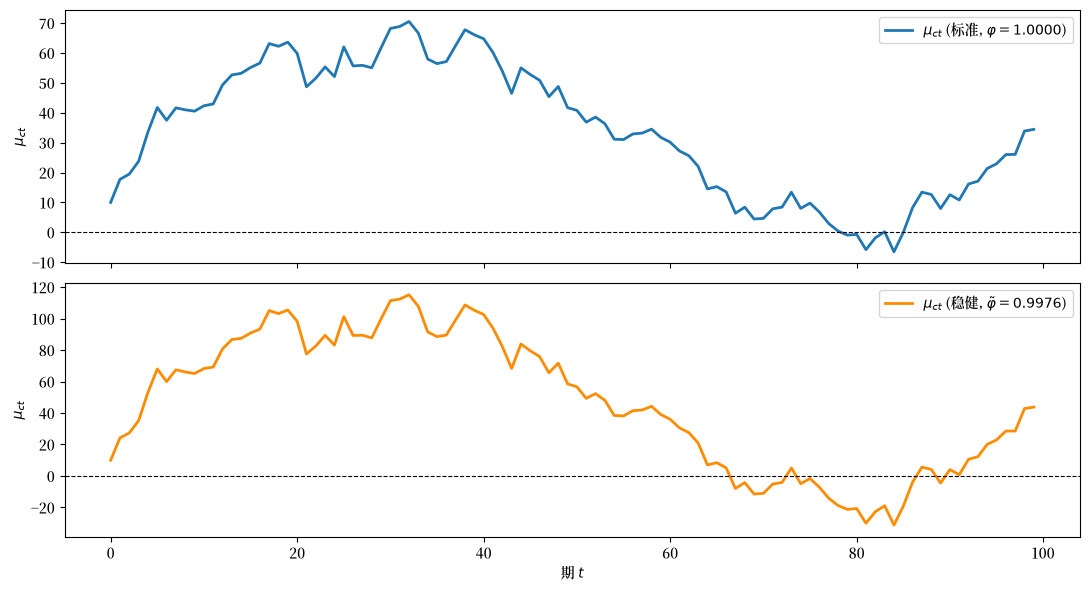

In [8]:
np.random.seed(0)
T_sim = 100

def simulate_ar1(φ, ν, shocks, mu0=0.0):
    path = np.empty(len(shocks) + 1)
    path[0] = mu0
    for t, ε in enumerate(shocks, start=1):
        path[t] = φ * path[t-1] + ν * ε
    return path

shock_path = np.random.randn(T_sim - 1)
mu0_init = 10.0
mu_std_path = simulate_ar1(φ_std, ν_std, shock_path, mu0=mu0_init)
mu_rob_path = simulate_ar1(φ_rob, ν_rob, shock_path, mu0=mu0_init)

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
t_grid = np.arange(T_sim)

axes[0].plot(t_grid, mu_std_path, lw=2, label=f'$\\mu_{{ct}}$ (标准, $\\varphi={φ_std:.4f}$)')
axes[0].axhline(0, color='k', lw=0.8, linestyle='--')
axes[0].set_ylabel('$\\mu_{ct}$')
axes[0].legend(loc='upper right')

axes[1].plot(t_grid, mu_rob_path, lw=2, color='darkorange',
             label=f'$\\mu_{{ct}}$ (稳健, $\\tilde{{\\varphi}}={φ_rob:.4f}$)')
axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
axes[1].set_xlabel('期 $t$')
axes[1].set_ylabel('$\\mu_{ct}$')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

### 观测等价性：稳健性表现得像耐心

{cite:t}`HansenSargent2001` 的一个关键洞见是，在永久收入模型中，对稳健性的偏好（$\sigma < 0$）*观测等价于*将贴现因子从 $\hat{\beta}$ 增加到一个更大的值 $\tilde{\beta}(\sigma)$，同时将 $\sigma$ 设回零。

等价轨迹由下式给出

```{math}
:label: eq:oe_locus
\tilde{\beta}(\sigma) =
    \frac{\hat{\beta}(1 + \hat{\beta})}{2(1 + \sigma\alpha^2)}
    \left[1 + \sqrt{1 - \frac{4\hat{\beta}(1+\sigma\alpha^2)}{(1+\hat{\beta})^2}}\right]
```

其中 $\alpha^2 = \tilde{\nu}^2$ 是稳健 AR(1) 表示 {eq}`eq:robust_ar1` 中的创新载荷平方。

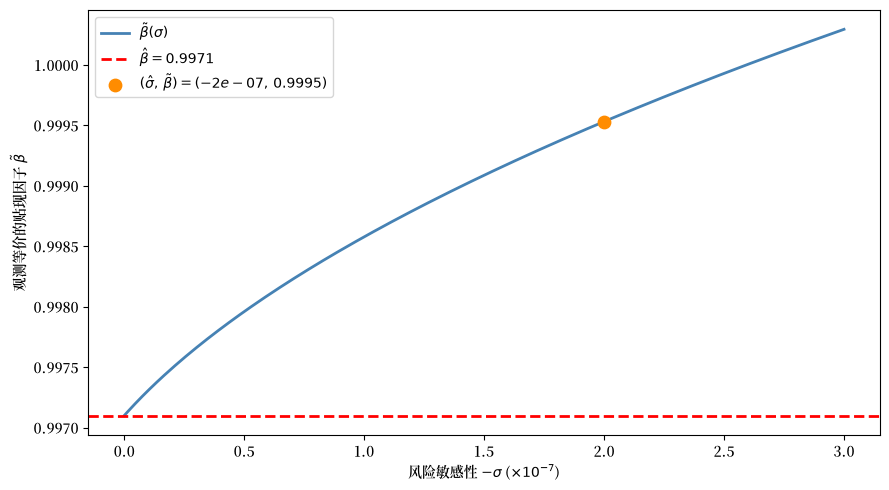

In [9]:
σ_range = np.linspace(-3e-7, 0.0, 200)
bt_vals = [beta_tilde(s, β_hat, α_sq) for s in σ_range]
bt_check = beta_tilde(σ_rs, β_hat, α_sq)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(-σ_range * 1e7, bt_vals, lw=2, color='steelblue',
        label='$\\tilde{\\beta}(\\sigma)$')
ax.axhline(β_hat, color='r', linestyle='--', lw=2,
           label=f'$\\hat{{\\beta}} = {β_hat}$')
ax.scatter([-σ_rs * 1e7], [bt_check], zorder=5, color='darkorange', s=80,
           label=f'$(\\hat{{\\sigma}},\\, \\tilde{{\\beta}}) '
                 f'= ({σ_rs:.0e},\\, {bt_check:.4f})$')
ax.set_xlabel('风险敏感性 $-\\sigma$ ($\\times 10^{-7}$)')
ax.set_ylabel('观测等价的贴现因子 $\\tilde{\\beta}$')
ax.legend()
plt.tight_layout()
plt.show()

该图证实了论文的关键发现：*激活对稳健性的偏好，就消费和储蓄行为而言，观测等价于增加贴现因子*。

然而，{cite:t}`HST_1999` 表明这两种参数化*并不*意味着相同的资产价格。

这是因为对稳健性的偏好通过进入随机贴现因子的 $\mathcal{D}(P)$ 矩阵生成了不同的状态价格。


## 小结

下表浓缩了主要结果：

| 设定 | 策略依赖于噪声？ | 使用的预测 | CE 是否成立？ |
|---------|:------------------------:|:--------------:|:------------:|
| Simon–Theil（普通 LQ） | 否 | 理性 | 是 |
| 稳健控制（乘数） | 是（$P$ 随 $f_2$ 和 $\theta$ 变化） | 扭曲（最坏情形） | 是（修正） |
| 风险敏感偏好 | 是（与稳健相同） | 扭曲（相同） | 是（相同） |

在所有这三种情形中，决策者都可以被描述为遵循一个两步流程：首先求解一个非随机控制问题，然后形成信念。

差异在于第二步中形成的是哪种信念。


## 练习

```{exercise-start}
:label: ce_ex2
```

数值地证明，当 $\theta \to \infty$ 时，稳健策略 $F(\theta)$ 收敛到标准 LQ 策略 $F_{\text{std}}$，且收敛速率为 $1/\theta$ 阶。在对数-对数尺度上绘制 $|F(\theta) - F_{\text{std}}|$ 对 $1/\theta$ 的图。

```{exercise-end}
```

```{solution-start} ce_ex2
:class: dropdown
```

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


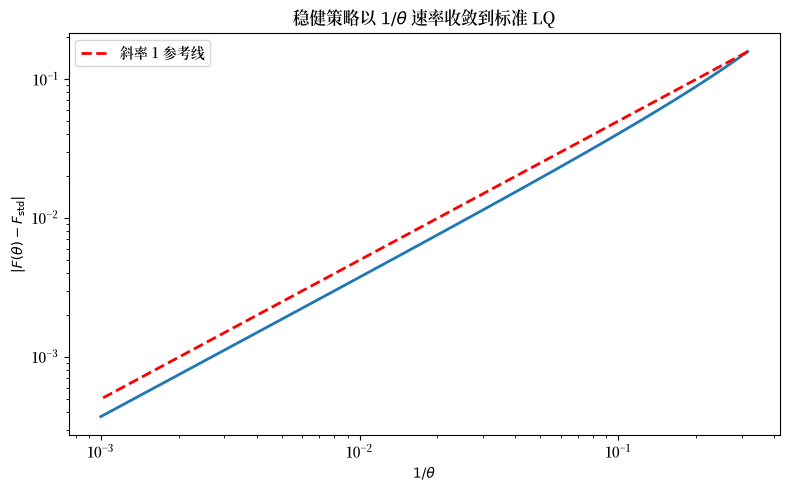

In [10]:
θ_large = np.logspace(0.5, 3.0, 100)
gap_vals = []

for θ in θ_large:
    rblq = RBLQ(R_mat, Q_mat, A, B, C_fixed, β, θ)
    F_r, _, _ = rblq.robust_rule()
    gap_vals.append(abs(float(F_r[0, 0]) - F_standard))

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(1.0 / θ_large, gap_vals, lw=2)
ax.set_xlabel('$1/\\theta$')
ax.set_ylabel('$|F(\\theta) - F_{\\mathrm{std}}|$')
ax.set_title('稳健策略以 $1/\\theta$ 速率收敛到标准 LQ')

x_ref = 1.0 / θ_large
ax.loglog(x_ref, x_ref * gap_vals[0] / x_ref[0],
          'r--', lw=2, label='斜率 1 参考线')
ax.legend()
plt.tight_layout()
plt.show()

对数-对数图揭示了一种近似线性的关系，证实了 $O(1/\theta)$ 收敛。

```{solution-end}
```

```{exercise-start}
:label: ce_ex3
```

选取三个值 $\sigma_i < 0$，并数值地验证带有 $(\sigma_i, \hat{\beta})$ 的稳健永久收入模型产生与带有 $(0, \tilde{\beta}_i)$ 的适当选择的非稳健模型相同的策略矩阵 $F$。

为了求出 $\tilde{\beta}_i$，从稳健闭环动态中提取 $\mu_{ct}$ 的 AR(1) 系数 $\varphi_i$，并设 $\tilde{\beta}_i = 1/(\varphi_i R)$。

证明在每种情形下 $\tilde{\beta}_i > \hat{\beta}$，从而确认稳健性表现得像增加的耐心。

```{exercise-end}
```

```{solution-start} ce_ex3
:class: dropdown
```

对于每个 $\sigma_i$，我们用 `RBLQ` 求解稳健问题，并从闭环动态 $A_{\text{cl}} = A - B F_{\text{rob}}$ 中提取 $\mu_{ct}$ 的 AR(1) 系数 $\varphi$。

如果 $F$ 是 $A_{\text{cl}}$ 的一个左特征向量，特征值为 $\varphi$，那么 $\mu_{ct} = -F y_t$ 满足 $\mu_{c,t+1} = \varphi\, \mu_{ct} + \nu\, \epsilon_{t+1}$。

设 $\tilde{\beta} = 1/(\varphi R)$ 并求解一个贴现因子为 $\tilde{\beta}$ 的标准（非稳健）LQ 问题应重现 $F$。

In [11]:
σ_trio = np.array([-5e-8, -1e-7, -2e-7])

for s in σ_trio:
    # 稳健模型：(σ, β_hat)
    θ_val = -1.0 / s
    rblq = RBLQ(R_pi, Q_pi, A_pi, B_pi, C_pi, β_hat, θ_val)
    F_rob, K_rob, P_rob = rblq.robust_rule()

    # 从近似模型下的闭环中提取 φ
    A_cl = A_pi - B_pi @ F_rob
    φ_rob = float((F_rob @ A_cl)[0, 1] / F_rob[0, 1])

    # 隐含的贴现因子
    bt = 1.0 / (φ_rob * R_rate)

    # 带有 β_tilde 的非稳健模型
    lq_nr = LQ(R_pi, Q_pi, A_pi, B_pi, C=C_pi, beta=bt)
    P_nr, F_nr, d_nr = lq_nr.stationary_values()

    print(f"σ = {s:.1e},  θ = {θ_val:.1e},  β̃ = {bt:.6f} (> β̂ = {β_hat})")
    print(f"  φ_rob = {φ_rob:.8f}")
    print(f"  F_robust  = [{F_rob[0,0]:.6f}, {F_rob[0,1]:.6f}]")
    print(f"  F_non-rob = [{F_nr[0,0]:.6f}, {F_nr[0,1]:.6f}]")
    print(f"  |F_rob - F_nr| = {np.max(np.abs(F_rob - F_nr)):.2e}")
    print(f"  K (最坏情形扭曲): [{K_rob[0,0]:.2e}, {K_rob[0,1]:.2e}]")
    print()

σ = -5.0e-08,  θ = 2.0e+07,  β̃ = 0.997472 (> β̂ = 0.9971)
  φ_rob = 0.99962721
  F_robust  = [0.003284, 0.884886]
  F_non-rob = [0.003284, 0.884894]
  |F_rob - F_nr| = 8.14e-06
  K (最坏情形扭曲): [2.48e-07, 6.68e-05]

σ = -1.0e-07,  θ = 1.0e+07,  β̃ = 0.997953 (> β̂ = 0.9971)
  φ_rob = 0.99914484
  F_robust  = [0.003766, 1.014865]
  F_non-rob = [0.003766, 1.014863]
  |F_rob - F_nr| = 2.05e-06
  K (最坏情形扭曲): [5.68e-07, 1.53e-04]

σ = -2.0e-07,  θ = 5.0e+06,  β̃ = 0.999522 (> β̂ = 0.9971)
  φ_rob = 0.99757687
  F_robust  = [0.005332, 1.437585]
  F_non-rob = [0.005333, 1.437465]
  |F_rob - F_nr| = 1.20e-04
  K (最坏情形扭曲): [1.61e-06, 4.34e-04]


策略矩阵 $F$ 高精度地匹配，证实了消费和储蓄决策的观测等价性。

在每种情形下 $\tilde{\beta} > \hat{\beta}$：对稳健性的偏好使得主体表现得好像他更有耐心。

稳健模型中非零的最坏情形扭曲 $K$ 在非稳健模型中没有对应物。

正如 {cite:t}`HST_1999` 所表明的，这就是为什么即使储蓄计划一致，这两种参数化仍然意味着不同的资产价格。

```{solution-end}
```